In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
# Cell 1: Import libraries and basic setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.19.0


In [3]:
# Cell 2: Load the splice-junction dataset and inspect it

# Update the file name if needed
df = pd.read_csv("dna.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
print()

# Show first 5 rows
display(df.head())

# Show column names
print("Columns:")
print(df.columns.tolist())
print()

# Check class distribution
print("Class distribution:")
print(df["class"].value_counts().sort_index())

Dataset loaded successfully.
Shape of dataset: (3186, 181)



,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A171,A172,A173,A174,A175,A176,A177,A178,A179,class
0,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,1,0,0,3
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
2,0,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,1,0,0,1,3
3,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,1
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,0,2


Columns:
['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A118', 'A119', 'A120', 'A121', 'A122', 'A123', 'A124', 'A125', 'A126', 'A127', 'A128', 'A129', 'A130', 'A131', 'A132', 'A133', 'A134', 'A135', 'A136', 'A13

In [4]:
# Cell 3: Prepare features and labels

# 1. Separate input features and target label
X = df.drop("class", axis=1).values
y = df["class"].values

print("Feature shape before reshape:", X.shape)
print("Label shape:", y.shape)
print()

# 2. Convert labels from 1,2,3 into 0,1,2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original classes:", sorted(df["class"].unique()))
print("Encoded classes:", sorted(np.unique(y_encoded)))
print()

# 3. Convert labels into categorical format
y_categorical = to_categorical(y_encoded)

print("Categorical label shape:", y_categorical.shape)
print()

# 4. Reshape X into (samples, 60, 3)
# because 180 binary features = 60 nucleotides × 3 binary indicators
X = X.reshape(X.shape[0], 60, 3)

print("Feature shape after reshape:", X.shape)

Feature shape before reshape: (3186, 180)
Label shape: (3186,)

Original classes: [np.int64(1), np.int64(2), np.int64(3)]
Encoded classes: [np.int64(0), np.int64(1), np.int64(2)]

Categorical label shape: (3186, 3)

Feature shape after reshape: (3186, 60, 3)


In [5]:
# Cell 4: Split dataset into 80% train, 10% validation, 10% test

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_categorical,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: divide temporary set into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (2548, 60, 3) (2548, 3)
Validation set: (319, 60, 3) (319, 3)
Test set: (319, 60, 3) (319, 3)


In [6]:
# Cell 5: Compute class weights

# Compute weights based on original encoded labels
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_encoded),
    y=y_encoded
)

# Convert to dictionary format required by Keras
class_weights = dict(enumerate(class_weights_values))

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(1.3846153846153846), 1: np.float64(1.388235294117647), 2: np.float64(0.6420798065296252)}


In [7]:
# Cell 6: Build the CNN + BiLSTM model

input_layer = Input(shape=(60, 3))

# CNN block 1
x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

# CNN block 2
x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

# BiLSTM layer
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

# Final layers
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output_layer = Dense(3, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,763 (522.51 KB)

 Trainable params: 133,379 (521.01 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# Cell 7: Compile the model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [9]:
# Cell 8: Train the model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

save_best = ModelCheckpoint(
    "best_splice_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, save_best],
    verbose=1
)

Epoch 1/50
73/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4364 - loss: 1.0653
Epoch 1: val_loss improved from None to 1.05465, saving model to best_splice_model.keras

Epoch 1: finished saving model to best_splice_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4643 - loss: 1.0067 - val_accuracy: 0.5047 - val_loss: 1.0547 - learning_rate: 0.0010
Epoch 2/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5410 - loss: 0.8787
Epoch 2: val_loss improved from 1.05465 to 1.02381, saving model to best_splice_model.keras

Epoch 2: finished saving model to best_splice_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5510 - loss: 0.8672 - val_accuracy: 0.5204 - val_loss: 1.0238 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6149 - loss: 0.7432
Epoch 3: val_loss did not improve from 1.02381
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6260 - loss: 0.7377 - val_accuracy: 0.4796 - val_loss: 1.0335 - learnin

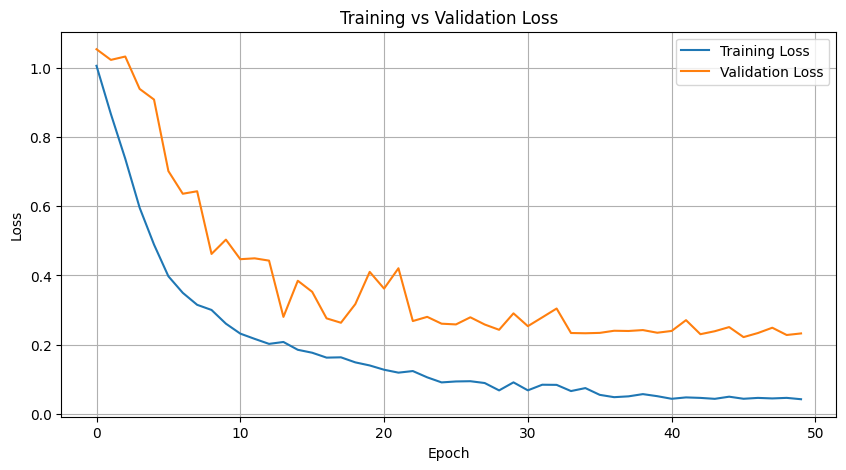

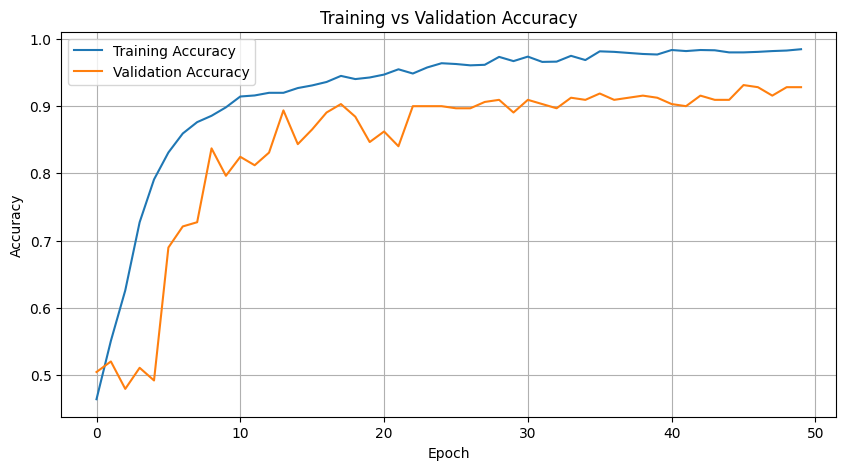

In [10]:
# Cell 9: Plot training and validation curves

# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curve
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Accuracy: 0.9435736677115988
Precision: 0.931230215257993
Recall: 0.9473450723450724
F1 Score: 0.938460529766588

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.94        77
           1       0.88      0.96      0.92        74
           2       0.98      0.93      0.96       168

    accuracy                           0.94       319
   macro avg       0.93      0.95      0.94       319
weighted avg       0.95      0.94      0.94       319



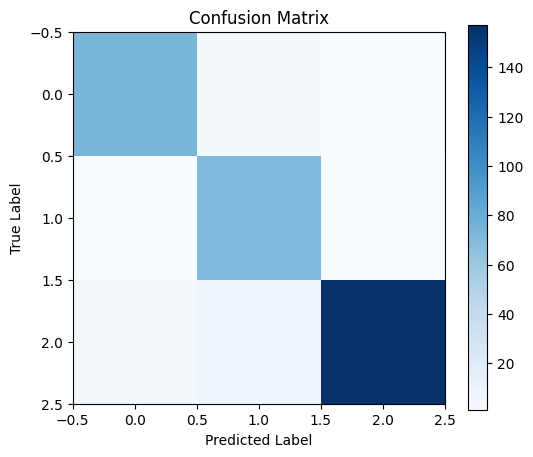

In [11]:
# Cell 10: Evaluate model performance on test set

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to predicted class
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot test labels to class index
y_true = np.argmax(y_test, axis=1)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

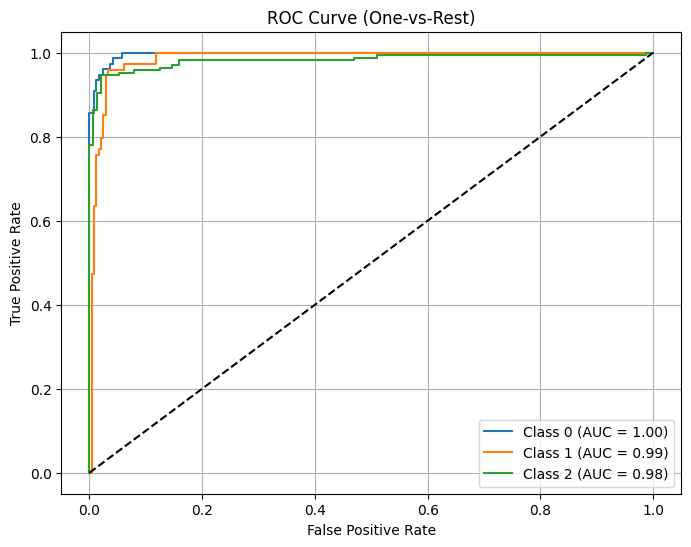

AUC scores per class: {0: np.float64(0.9969410754534721), 1: np.float64(0.9859900717043574), 2: np.float64(0.9820640176600443)}


In [12]:
# Cell 11: ROC Curve and AUC Score for multi-class classification

from sklearn.preprocessing import label_binarize

# Number of classes
n_classes = y_test.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1], [0,1], "k--")  # random guess line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

print("AUC scores per class:", roc_auc)

In [13]:
# Cell 12: Baseline model comparison

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Convert one-hot labels back to single class labels
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Flatten X for classical ML models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

results = []

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_flat, y_train_labels)
lr_pred = lr_model.predict(X_test_flat)

results.append([
    "Logistic Regression",
    accuracy_score(y_test_labels, lr_pred),
    precision_score(y_test_labels, lr_pred, average="macro"),
    recall_score(y_test_labels, lr_pred, average="macro"),
    f1_score(y_test_labels, lr_pred, average="macro")
])

# SVM
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train_flat, y_train_labels)
svm_pred = svm_model.predict(X_test_flat)

results.append([
    "SVM",
    accuracy_score(y_test_labels, svm_pred),
    precision_score(y_test_labels, svm_pred, average="macro"),
    recall_score(y_test_labels, svm_pred, average="macro"),
    f1_score(y_test_labels, svm_pred, average="macro")
])

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_model.fit(X_train_flat, y_train_labels)
rf_pred = rf_model.predict(X_test_flat)

results.append([
    "Random Forest",
    accuracy_score(y_test_labels, rf_pred),
    precision_score(y_test_labels, rf_pred, average="macro"),
    recall_score(y_test_labels, rf_pred, average="macro"),
    f1_score(y_test_labels, rf_pred, average="macro")
])

# CNN + BiLSTM results
results.append([
    "CNN + BiLSTM",
    accuracy,
    precision,
    recall,
    f1
])

# Show comparison table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.959248,0.957108,0.954921,0.955998
1,SVM,0.968652,0.961322,0.968083,0.964606
2,Random Forest,0.956113,0.952585,0.950943,0.951415
3,CNN + BiLSTM,0.943574,0.931230,0.947345,0.938461


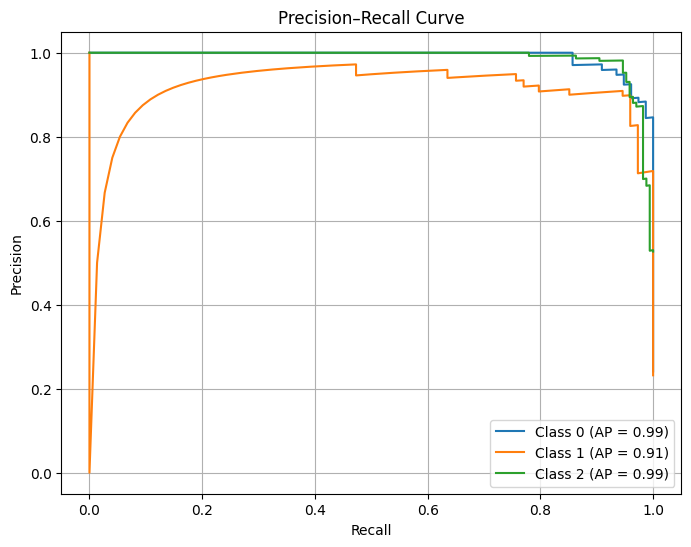

Average Precision per class: {0: np.float64(0.9909316831048683), 1: np.float64(0.9148419898918347), 2: np.float64(0.9880596916159483)}


In [14]:
# Cell 13: Precision–Recall Curve for multi-class classification

from sklearn.metrics import precision_recall_curve, average_precision_score

n_classes = y_test.shape[1]

precision = {}
recall = {}
avg_precision = {}

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
    avg_precision[i] = average_precision_score(y_test[:, i], y_pred_prob[:, i])

    plt.plot(
        recall[i],
        precision[i],
        label=f"Class {i} (AP = {avg_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision per class:", avg_precision)

In [15]:
# Cell 14: Save the trained model and main results

# 1. Save final trained model
model.save("final_cnn_bilstm_splice_model.keras")
print("Model saved successfully.")

# 2. Save results table
results_df.to_csv("model_comparison_results.csv", index=False)
print("Results table saved successfully.")

# 3. Save main metrics in a text file
with open("final_model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"AUC Scores: {roc_auc}\n")
    f.write(f"Average Precision Scores: {avg_precision}\n")

print("Metrics saved successfully.")

Model saved successfully.
Results table saved successfully.
Metrics saved successfully.
